# **1. Lectura de paquetes y data**


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import ExponentialSmoothing, ARIMA
from itertools import product
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
import os
import optuna
import time
import sys
sys.path.append("../src/utils")

from evaluacion_recursiva import (
    evaluate_regression_model_with_recursive_window,
    evaluate_autoarima_with_recursive_window,
    evaluate_holtwinters_with_recursive_window,
    optimize_holtwinters_with_optuna,
    evaluate_arima_with_recursive_window
)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

C:\Users\a7854\anaconda3\envs\Analisis_de_datos_I\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Utilizamos paths relativos para la lectura de la data

In [2]:
filename = "Evaluacion_modelos_st_AC.ipynb"  # nombre del archivo actual
print(f"Current absolute path: {os.getcwd()}\n")

# Especificamos la ruta del directorio actual y los directorios de datos y salida
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(ACTUAL_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "output")

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Current absolute path: C:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Proyecto de Innovacion Tecnologica\Taller Final\innv_tec_1_icesi\notebooks

BASE_DIR: C:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Proyecto de Innovacion Tecnologica\Taller Final\innv_tec_1_icesi
DATA_DIR: C:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Proyecto de Innovacion Tecnologica\Taller Final\innv_tec_1_icesi\data
OUTPUT_DIR: C:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Proyecto de Innovacion Tecnologica\Taller Final\innv_tec_1_icesi\data\output


In [3]:
# Cargar el archivo de Excel
file_path = os.path.join(DATA_DIR, "data_demanda.xlsx")
df_base = pd.read_excel(file_path, sheet_name="data")
df_base = df_base.drop("Cliente", axis=1)

In [4]:
df_base

,Fe.prefer.entrega,Day_of_the_Week,Pedidos,Sell_In,Sell_in_on_time,CEDIS,SKU,Mes_Año,Sell_in_rezago,porcentaje_on_time,Subcategoria
0,2024-07-05,Friday,16200,16200,16200,7,SKU7,72024,0,1.000000,BEBIDAS DE YOGUR
1,2024-07-05,Friday,19800,19800,19800,6,SKU5,72024,0,1.000000,BEBIDAS DE YOGUR
2,2024-07-05,Friday,4950,4950,4950,4,SKU6,72024,0,1.000000,BEBIDAS DE YOGUR
3,2024-07-05,Friday,8100,8100,8100,6,SKU4,72024,0,1.000000,BEBIDAS DE YOGUR
4,2024-07-05,Friday,18600,18600,18600,7,SKU3,72024,0,1.000000,BEBIDAS DE YOGUR
...,...,...,...,...,...,...,...,...,...,...,...
6829,2025-04-10,Thursday,1560,1560,1560,2,SKU14,42025,0,1.000000,FIOCOSSOS
6830,2025-04-10,Thursday,3900,3900,3900,2,SKU16,42025,0,1.000000,LECHE PASTEURIZADA
6831,2025-04-10,Thursday,4200,0,0,3,SKU8,42025,0,0.000000,YOGUR BOTELLA
6832,2025-04-10,Thursday,2160,1764,1764,3,SKU22,42025,0,0.816667,YOGUR VASOS


In [5]:
# Filtrar los datos relevantes para este analisis

df = (
    df_base[["Fe.prefer.entrega", "SKU", "Pedidos"]]
    .copy()
    .rename(
        columns={
            "Fe.prefer.entrega": "Fecha",
        }
    )
)
df["Pedidos"] = pd.to_numeric(df["Pedidos"], errors="coerce")

In [6]:
df

,Fecha,SKU,Pedidos
0,2024-07-05,SKU7,16200
1,2024-07-05,SKU5,19800
2,2024-07-05,SKU6,4950
3,2024-07-05,SKU4,8100
4,2024-07-05,SKU3,18600
...,...,...,...
6829,2025-04-10,SKU14,1560
6830,2025-04-10,SKU16,3900
6831,2025-04-10,SKU8,4200
6832,2025-04-10,SKU22,2160


In [7]:
### Primero, nos aseguramos de que se cuente un dato por SKU por dia
# -------

# rango completo de fechas desde la más antigua hasta la más reciente
fecha_min = df["Fecha"].min()
fecha_max = df["Fecha"].max()
rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq="D")

# Obtenemos todos los SKUs únicos
skus = df["SKU"].unique()

# DataFrame con todas las combinaciones de SKU y fecha
combinaciones_completas = pd.MultiIndex.from_product(
    [rango_fechas, skus], names=["Fecha", "SKU"]
).to_frame(index=False)

# Unir con el dataframe original para rellenar con ceros donde falten datos
df_completo = combinaciones_completas.merge(df, on=["Fecha", "SKU"], how="left")

# Rellenar valores faltantes de pedidos con 0
df_completo["Pedidos"] = df_completo["Pedidos"].fillna(0).astype(int)

# Ordenar por SKU y Fecha (opcional)
df_completo = df_completo.sort_values(["SKU", "Fecha"]).reset_index(drop=True)

df = df_completo.copy()

In [8]:
df

,Fecha,SKU,Pedidos
0,2024-07-05,SKU1,7200
1,2024-07-06,SKU1,7200
2,2024-07-07,SKU1,7200
3,2024-07-08,SKU1,3000
4,2024-07-09,SKU1,3000
...,...,...,...
7275,2025-04-06,SKU9,420
7276,2025-04-07,SKU9,1200
7277,2025-04-08,SKU9,1200
7278,2025-04-09,SKU9,2760


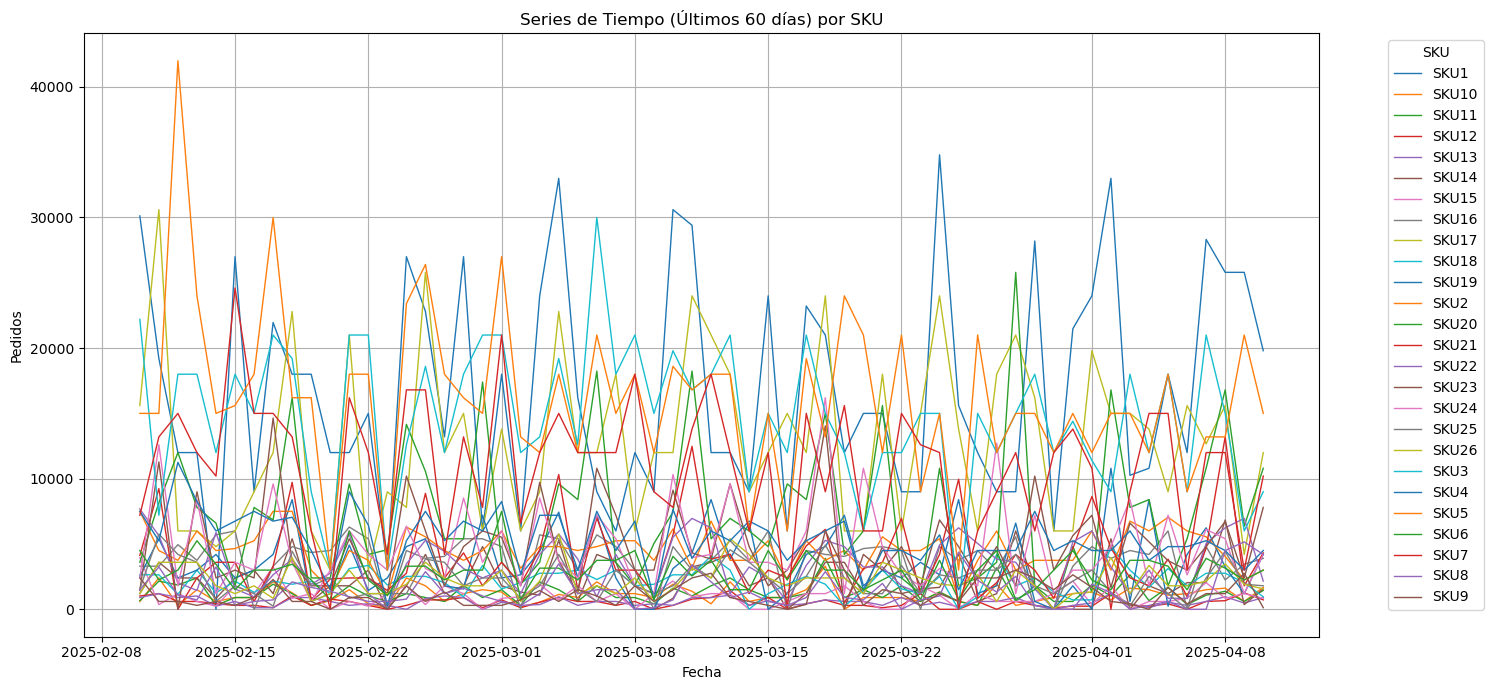

In [9]:
### Grafico de series de tiempo para todos los SKU (ultimos 60 dias)

# Asegurar que la columna Fecha tenga tipo datetime
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

# Calcular la fecha límite: últimos 60 días desde la fecha máxima
fecha_max = df["Fecha"].max()
fecha_min = fecha_max - pd.Timedelta(days=59)

# Filtrar el DataFrame a los últimos 60 días
df_ultimos_60 = df[df["Fecha"].between(fecha_min, fecha_max)].copy()

# Eliminar filas con datos faltantes
df_ultimos_60 = df_ultimos_60.dropna(subset=["Fecha", "Pedidos"])

# Asegurarse de que Pedidos sea numérico
df_ultimos_60["Pedidos"] = pd.to_numeric(df_ultimos_60["Pedidos"], errors="coerce")

# Graficar
plt.figure(figsize=(15, 7))

for sku in df_ultimos_60["SKU"].unique():
    datos_sku = df_ultimos_60[df_ultimos_60["SKU"] == sku]
    plt.plot(datos_sku["Fecha"].values, datos_sku["Pedidos"].values, label=sku, linewidth=1)

# Títulos y etiquetas
plt.title("Series de Tiempo (Últimos 60 días) por SKU")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend(title="SKU", bbox_to_anchor=(1.05, 1), loc="upper left")  # Leyenda afuera
plt.tight_layout()
plt.grid(True)
plt.show()

# 1. Identificación de tipo de demanda

 A continuación, clasificaremos la demanda de productos (SKU) según su variabilidad (CoV) y frecuencia (INT o ADI), y asignarles una categoría basada en estas métricas para futuros modelos a evaluar.

In [10]:
# Función para calcular CoV e Intermitencia (ADI)
def classify_demand(group):
    demand_series = group["Pedidos"].fillna(0)
    total_periods = len(demand_series)
    non_zero_periods = (demand_series > 0).sum()

    # Coeficiente de variación (CoV)
    mean = demand_series.mean()
    std = demand_series.std()
    cov = (std / mean) * 100 if mean > 0 else np.nan

    # Intermitencia (ADI)
    adi = total_periods / non_zero_periods if non_zero_periods > 0 else np.nan

    return pd.Series(
        {
            "CoV": cov,
            "INT": adi,
            "Periods": total_periods,
            "NonZeroPeriods": non_zero_periods,
        }
    )


# Agrupar por SKU
demand_classification = df.groupby("SKU").apply(classify_demand).reset_index()

In [11]:
# Clasificación CoV
def classify_cov(cov):
    if pd.isna(cov):
        return 5
    elif cov > 33.3:
        return 1
    elif 20.8 < cov <= 33.3:
        return 2
    elif 8.3 < cov <= 20.8:
        return 3
    elif 0 <= cov <= 8.3:
        return 4
    else:
        return 5


# Clasificación INT
def classify_int(adi):
    if pd.isna(adi):
        return 5
    elif adi > 1.32:
        return 1  # Alta intermitencia
    elif 1.1 < adi <= 1.32:
        return 2  # Moderada intermitencia
    elif 1.0 < adi <= 1.1:
        return 3  # Casi continua
    elif adi == 1.0:
        return 4  # Completamente continua
    else:
        return 5


# Aplicar puntajes
demand_classification["CoV_Score"] = demand_classification["CoV"].apply(classify_cov)
demand_classification["INT_Score"] = demand_classification["INT"].apply(classify_int)
demand_classification["Total_Score"] = (
    demand_classification["CoV_Score"] + demand_classification["INT_Score"]
)

In [12]:
def demand_category(score):
    if score <= 2:
        return "Erratic"
    elif score <= 4:
        return "Irregular"
    elif score <= 6:
        return "Uneven"
    elif score <= 8:
        return "Smooth"
    else:
        return "No Demand"


demand_classification["Classification"] = demand_classification["Total_Score"].apply(
    demand_category
)

In [13]:
# Mostrar resultados ordenados por SKU
demand_classification.sort_values(by="SKU").head(100)

,SKU,CoV,INT,Periods,NonZeroPeriods,CoV_Score,INT_Score,Total_Score,Classification
0,SKU1,91.094254,1.142857,280.0,245.0,1,2,3,Irregular
1,SKU10,57.910204,1.044776,280.0,268.0,1,3,4,Irregular
2,SKU11,60.703733,1.044776,280.0,268.0,1,3,4,Irregular
3,SKU12,73.264954,1.115538,280.0,251.0,1,2,3,Irregular
4,SKU13,69.736909,1.124498,280.0,249.0,1,2,3,Irregular
5,SKU14,85.505733,1.085271,280.0,258.0,1,3,4,Irregular
6,SKU15,83.734416,1.201717,280.0,233.0,1,2,3,Irregular
7,SKU16,49.207020,1.166667,280.0,240.0,1,2,3,Irregular
8,SKU17,73.933485,1.085271,280.0,258.0,1,3,4,Irregular
9,SKU18,53.938336,1.040892,280.0,269.0,1,3,4,Irregular


# **2. Selección de Modelos de Series de Tiempo**

A partir de la clasificación que le asignamos a cada SKU, elegiremos un set de modelos a implementar por cada tipo de demanda.


| **Clasificación** | **Modelos sugeridos (Model Set)**                                                       | **Notas clave**                             |
| ----------------- | --------------------------------------------------------------------------------------- | ------------------------------------------- |
| **Smooth**        | Exponential Smoothing, Moving Average                                                   | Baja variabilidad, no hay tendencia marcada |
| **Uneven**        | Holt-Winters (Additive o Multiplicative), ARIMA, Double Exponential                     | Variabilidad moderada, posibles patrones    |
| **Irregular**     | ARIMA, Stepwise ARIMA, Holt-Winters, Double Exponential                                 | Tendencias leves, más ruido                 |
| **Erratic**       | Croston’s, Intermittent Demand Methods (TSB, SBA si se quiere extender), Moving Average | Demanda muy esporádica                      |
| **No Demand**     | No se modela (forecast = 0 o revisión manual)                                           | No aplica modelo estadístico                |


Flujo a implementar por cada SKU:

1. Usar la clasificación calculada.

2. Asignar el conjunto de modelos correspondiente.

3. Simular cada modelo del conjunto.

4. Calcular errores (ej. MAE, RMSE, MAPE).

5. Seleccionar el Best Fit (modelo con menor error).

6. Guardar el forecast.

In [14]:
# Función para asignar model set:


def assign_model_set(classification):
    if classification == "Smooth":
        return ["exp_smoothing", "moving_average"]
    elif classification == "Uneven":
        return ["holt_winters", "holt_winters_additive", "arima", "double_exp"]
    elif classification == "Irregular":
        return ["arima", "stepwise_arima", "holt_winters", "double_exp"]
    elif classification == "Erratic":
        return ["croston", "moving_average"]
    else:
        return []


demand_classification["Model_Set"] = demand_classification["Classification"].apply(
    assign_model_set
)

# **3. Corrección de Outliers**

Con el objetivo de evitar valores puntuales considerados como outliers con potencial de afectar el entrenamiento o proyección, se realiza una corrección **POR SKU**

In [15]:
# Corregir outliers por SKU
def correct_outliers(group):
    series = group["Pedidos"].copy()
    mean = series.mean()
    std = series.std()
    lower = mean - 2 * std
    upper = mean + 2 * std
    series = series.apply(lambda x: lower if x < lower else upper if x > upper else x)
    group["Pedidos_Clean"] = series
    return group


df_cleaned = df.groupby("SKU").apply(correct_outliers).reset_index(drop=True)

In [16]:
df_cleaned[["Pedidos", "Pedidos_Clean"]].describe()

,Pedidos,Pedidos_Clean
count,7280.000000,7280.000000
mean,4471.113874,4390.077312
std,6050.360538,5729.989458
min,0.000000,0.000000
25%,840.000000,840.000000
50%,2400.000000,2400.000000
75%,5400.000000,5400.000000
max,84600.000000,44144.159257


# **4. Funciones de evaluación y modelos**

Procedemos a definir funciones para evaluar modelos de series de tiempo, específicamente los modelos Holt-Winters (suavizamiento exponencial) y ARIMA, aplicando una búsqueda en rejilla (grid search) sobre distintos parámetros. 

El objetivo es encontrar la configuración con mejor desempeño, evaluada mediante métricas como MAE, RMSE y MAPE.

In [17]:
# Calcula el error porcentual absoluto medio (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Evita división por cero: solo considera valores donde y_true ≠ 0
    non_zero = y_true != 0

    # Calcula el MAPE sobre esos valores
    return (
        np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100
    )


# Divide una serie en entrenamiento y prueba
def split_series(series, test_size=7):
    return series[:-test_size], series[-test_size:]


# Evalúa múltiples configuraciones del modelo Holt-Winters y devuelve la mejor

def evaluate_holt_winters(train, test, seasonal_periods=7):
    best_result = None

    for trend in [None, "add", "mul"]:
        for seasonal in [None, "add", "mul"]:
            for alpha, beta, gamma in product([0.2, 0.4, 0.6, 0.8], repeat=3):
                try:
                    model = ExponentialSmoothing(
                        train,
                        trend=trend,
                        seasonal=seasonal,
                        seasonal_periods=seasonal_periods,
                    ).fit(
                        smoothing_level=alpha,
                        smoothing_slope=beta,
                        smoothing_seasonal=gamma,
                        optimized=False,
                    )

                    # Predicción con mínimo 0
                    forecast_raw = model.forecast(len(test))
                    forecast = np.maximum(forecast_raw, 0)

                    mae = mean_absolute_error(test, forecast)
                    rmse = np.sqrt(mean_squared_error(test, forecast))
                    mape = mean_absolute_percentage_error(test, forecast)

                    config = f"HW-{trend}-{seasonal}-a{alpha}-b{beta}-g{gamma}"
                    result = {
                        "model": config,
                        "mae": mae,
                        "rmse": rmse,
                        "mape": mape,
                        "forecast": forecast.tolist(),
                    }

                    if best_result is None or rmse < best_result["rmse"]:
                        best_result = result
                except:
                    continue

    return best_result



# Evalúa múltiples configuraciones del modelo ARIMA y devuelve la mejor


def evaluate_auto_arima(train, test, seasonal=False, m=1):
    try:
        model = auto_arima(
            train,
            seasonal=seasonal,
            m=m,  # periodicidad estacional si aplica
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False
        )

        # Hacer predicción y forzar a cero mínimo
        forecast_raw = model.predict(n_periods=len(test))
        forecast = np.maximum(forecast_raw, 0)

        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        mape = mean_absolute_percentage_error(test, forecast)

        return {
            "model": str(model.order) if not seasonal else f"ARIMA{model.order}x{model.seasonal_order}",
            "mae": mae,
            "rmse": rmse,
            "mape": mape,
            "forecast": forecast.tolist()
        }
    except Exception as e:
        return None



# **5. Evaluación de Modelos**

A continuación, implementamos un pipeline automatizado para:
- Evaluar modelos de series de tiempo (ARIMA y Holt-Winters) para cada SKU.
- Seleccionar el mejor modelo por SKU en función del RMSE.
- Guardar un resumen de las métricas de desempeño y el pronóstico generado.

También utilizamos el paquete tqdm para mostrar una barra de progreso durante la ejecución.

In [18]:
# Automatizar evaluación y forecasting para todos los SKUs
from tqdm import tqdm  # para barra de progreso (opcional en Colab)


# Función principal que automatiza el proceso de modelado por SKU
def run_full_forecast_pipeline(df, seasonal_periods=7):
    skus = df["SKU"].unique()
    #skus = df[df["SKU"] == "SKU12"]["SKU"].tolist()
    #print(skus)
    forecast_results = []
    start_global = time.time()
    # Itera sobre cada SKU con barra de progreso
    for sku in tqdm(skus, desc="Evaluando SKUs"):
        #print(sku)
        start_time = time.time()
        # Extrae la serie temporal del SKU actual (ya corregida de outliers)
        series = df[df["SKU"] == sku]["Pedidos_Clean"].reset_index(drop=True)
        #print(series)
        # Divide la serie en entrenamiento y prueba
        #train, test = split_series(series)
        results = []  # Lista para guardar los resultados de los modelos evaluados

        # --- Modelo ARIMA ---
        #arima_result = evaluate_auto_arima(train, test)
        #arima_result = evaluate_autoarima_with_recursive_window(series)
        arima_result=  evaluate_arima_with_recursive_window(series)
        #print('break')
        #print(pd.DataFrame(arima_result))
        if arima_result is not None :
            if arima_result["rmse"] != np.inf:
                results.append(arima_result.to_dict())  # Guarda resultado si fue exitoso

        # --- Modelo Holt-Winters ---
        #holt_result = evaluate_holt_winters(train, test, seasonal_periods)
        best_params = optimize_holtwinters_with_optuna(series, seasonal_periods=seasonal_periods, n_trials=500)
        if best_params:
            holt_result = evaluate_holtwinters_with_recursive_window(series, best_params, seasonal_periods=seasonal_periods)
            if holt_result and holt_result["rmse"] != np.inf:
                results.append(holt_result)


        # Ordena los resultados por RMSE (menor es mejor)
        results_sorted = sorted(results, key=lambda x: x["rmse"])
        
        best_result = (
            results_sorted[0] if results_sorted else None
        )  # Toma el mejor modelo
        #print(best_result)
        # Si hay al menos un resultado válido, guarda el resumen
        #if best_result:
        #    forecast_results.append(
        #        {
        #            "SKU": sku,
        #            "Best_Model": best_result[
        #                "model"
        #            ],  # Nombre/configuración del mejor modelo
        #            "MAE": best_result["mae"],
        #            "RMSE": best_result["rmse"],
        #            "MAPE": best_result["mape"],
        #            "Forecast": best_result[
        #                "forecast"
        #            ],  # Lista de valores pronosticados
        #        }
        #    )
        #print(type(best_result))
        if  best_result:
            forecast_results.append({
                "SKU": sku,
                "Best_Model": best_result.get("model", "N/A"),
                "MAE": best_result.get("mae", np.nan),
                "RMSE": best_result.get("rmse", np.nan),
                "MAPE": best_result.get("mape", np.nan),
                #"Forecast": best_result.get("forecast", []),
                "Params": best_result.get("params", {})
            })

        elapsed = time.time() - start_time
        print(f"⏱️  {sku} procesado en {elapsed:.2f} segundos")

    total_time = time.time() - start_global
    print(f"🏁 Evaluación completada en {total_time/60:.2f} minutos")

    # Devuelve un DataFrame con los resultados para todos los SKUs
    return pd.DataFrame(forecast_results)


# Asegurarse que todas las series terminan el domingo 13 de abril de 2025
#fecha_maxima_valida = pd.to_datetime("2025-04-10")
#print(df_cleaned.describe)
fecha_maxima_valida = pd.to_datetime("2025-04-03")
fecha_minima_valida = pd.to_datetime("2024-07-05")

df_cleaned = df_cleaned[(df_cleaned["Fecha"] <= fecha_maxima_valida) & (df_cleaned["Fecha"] >= fecha_minima_valida)].reset_index(drop=True)

#print(df_cleaned)
# Ejecutar el pipeline completo
df_forecast_summary = run_full_forecast_pipeline(df_cleaned)

# Mostrar resultados
df_forecast_summary.head(100)

Evaluando SKUs:   4%|▍         | 1/26 [00:27<11:35, 27.81s/it]

⏱️  SKU1 procesado en 27.81 segundos
error2,2,2


Evaluando SKUs:   8%|▊         | 2/26 [01:00<12:22, 30.94s/it]

⏱️  SKU10 procesado en 33.13 segundos


Evaluando SKUs:  12%|█▏        | 3/26 [01:34<12:20, 32.18s/it]

...

Evaluando SKUs:  96%|█████████▌| 25/26 [12:37<00:29, 29.37s/it]

⏱️  SKU8 procesado en 28.22 segundos
error2,2,2


Evaluando SKUs: 100%|██████████| 26/26 [13:04<00:00, 30.16s/it]

⏱️  SKU9 procesado en 26.63 segundos
🏁 Evaluación completada en 13.07 minutos


,SKU,Best_Model,MAE,RMSE,MAPE,Params
0,SKU1,Holt-Winters,5252.466154,6737.557422,30.602696,"{'trend': 'add', 'seasonal': 'add', 'alpha': 0..."
1,SKU10,Holt-Winters,321.414366,404.019510,inf,"{'trend': 'add', 'seasonal': 'add', 'alpha': 0..."
2,SKU11,Holt-Winters,396.533944,456.282784,49.312226,"{'trend': 'add', 'seasonal': 'add', 'alpha': 0..."
3,SKU12,"ARIMA(1,0,2)",266.346560,312.733717,67.099155,"(1, 0, 2)"
4,SKU13,Holt-Winters,154.746315,207.260224,inf,"{'trend': 'add', 'seasonal': 'add', 'alpha': 0..."
5,SKU14,Holt-Winters,1208.871518,1403.819794,inf,"{'trend': 'add', 'seasonal': 'add', 'alpha': 0..."
6,SKU15,Holt-Winters,463.139380,521.505389,inf,"{'trend': 'add', 'seasonal': 'add', 'alpha': 0..."
7,SKU16,Holt-Winters,718.528222,1021.214195,383.064415,"{'trend': 'mul', 'seasonal': 'add', 'alpha': 0..."
8,SKU17,Holt-Winters,4702.470048,5227.167699,46.717985,"{'trend': 'add', 'seasonal': 'add', 'alpha': 0..."
9,SKU18,"ARIMA(2,0,2)",992.695694,1214.059614,93.049994,"(2, 0, 2)"


In [26]:
df_forecast_summary

# Lista donde se guardarán las métricas finales
resultados_futuro = []
df_test= df.groupby("SKU").apply(correct_outliers).reset_index(drop=True)
#print (df_test)
# Iterar por cada SKU con su mejor modelo
for _, fila in df_forecast_summary.iterrows():
    sku = fila["SKU"]
    modelo = fila["Best_Model"]
    params = fila["Params"]
    
    # Obtener la serie correspondiente
    fecha_maxima_valida_prueba = pd.to_datetime("2025-04-10")
    fecha_minima_valida_prueba = pd.to_datetime("2024-07-05")

    #df_cleaned = df_cleaned[(df_cleaned["Fecha"] <= fecha_maxima_valida) & (df_cleaned["Fecha"] >= fecha_minima_valida)].reset_index(drop=True)

    serie = df_test[(df_test["SKU"] == sku) & (df_test["Fecha"] <= fecha_maxima_valida_prueba) & (df_test["Fecha"] >= fecha_minima_valida_prueba)]["Pedidos_Clean"].reset_index(drop=True)
    #serie = df_test['SKU'=sku]
    #print (serie)
    # Separar últimos 7 días como test
    if len(serie) < 14:
        continue  # omitir series muy cortas
    y_train = serie[:-7]
    y_test = serie[-7:]
    #print(y_test)
    try:
        # ARIMA
        if "ARIMA" in modelo:
            p, d, q = params  # es una tupla
            model_fit = ARIMA(y_train, order=(p, d, q)).fit()
            forecast = model_fit.forecast(steps=7)
            forecast = np.where(forecast < 0, 0, forecast)
            modelo = f"ARIMA(p{p}-d{d}-q{q})"
        # Holt-Winters
        elif "Holt-Winters" in modelo:
            model_fit = ExponentialSmoothing(
                y_train,
                trend=params.get("trend"),
                seasonal=params.get("seasonal"),
                seasonal_periods=7
            ).fit(
                smoothing_level=params.get("alpha"),
                smoothing_slope=params.get("beta"),
                smoothing_seasonal=params.get("gamma")
            )
            trend=params.get("trend")
            seasonal=params.get("seasonal")
            smoothing_level=round(params.get("alpha"),2)
            smoothing_slope=round(params.get("beta"),2)
            smoothing_seasonal=round(params.get("gamma"),2)
            forecast = model_fit.forecast(7)
            forecast = np.where(forecast < 0, 0, forecast)
            modelo = f"HW-Trend({trend})-seasonal({seasonal})-a{smoothing_level}-b{smoothing_slope}-g{smoothing_seasonal}"

        # Cálculo de métricas
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        mae = mean_absolute_error(y_test, forecast)
        mape = mean_absolute_percentage_error(y_test,forecast)

        # Guardar resultado
        resultados_futuro.append({
            "SKU": sku,
            "Modelo": modelo,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            #"y_test": y_test.tolist(),
            "forecast": forecast.tolist()
        })

    except Exception as e:
        print(f"⚠️ Error en SKU {sku}: {e}")
        continue


In [27]:
resultados_futuro_df=pd.DataFrame(resultados_futuro)

In [28]:
resultados_futuro_df.to_excel(
    os.path.join(OUTPUT_DIR, "forecast_results_Recursivo.xlsx"),
    index=False,
)

In [29]:
def plot_forecast_focus(df, sku, forecast_result, test_size=7, context_window=5):
    series = df[df["SKU"] == sku]["Pedidos_Clean"].reset_index(drop=True)
    train, test = split_series(series, test_size=test_size)
    forecast = forecast_result["forecast"]
    model_name = forecast_result["Modelo"]

    context_len = test_size * context_window
    plot_start = max(0, len(train) - context_len)

    plt.figure(figsize=(12, 5))

    # Plot del histórico reciente
    plt.plot(
        range(plot_start, len(train)),
        train.iloc[plot_start:].values,
        label="Train",
        color="gray"
    )

    # Línea de corte
    plt.axvline(x=len(train) - 1, color="black", linestyle="--", label="Train/Test split")

    # Forecast
    plt.plot(
        range(len(train), len(train) + test_size),
        forecast,
        label=f"Forecast ({model_name})",
        color="blue"
    )

    # Valores reales del test
    plt.plot(
        range(len(train), len(train) + test_size),
        test.values,
        label="Test Real",
        color="orange"
    )

    plt.title(f"SKU: {sku} | Modelo: {model_name}")
    plt.xlabel("Periodo")
    plt.ylabel("Pedidos")
    plt.legend()
    plt.grid(True)
    plt.show()


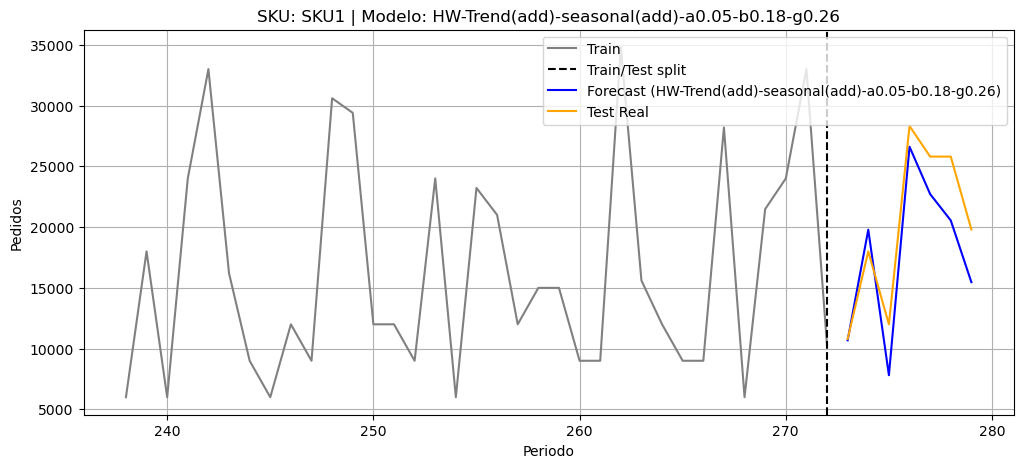

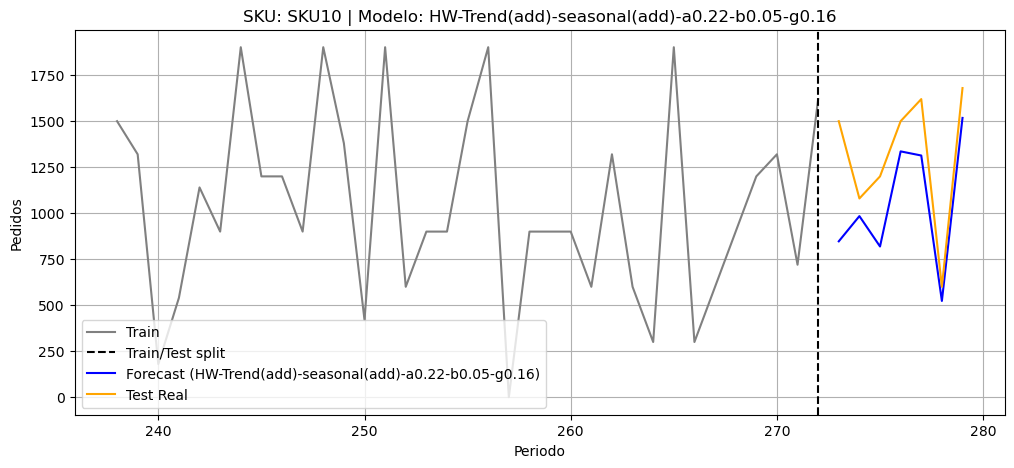

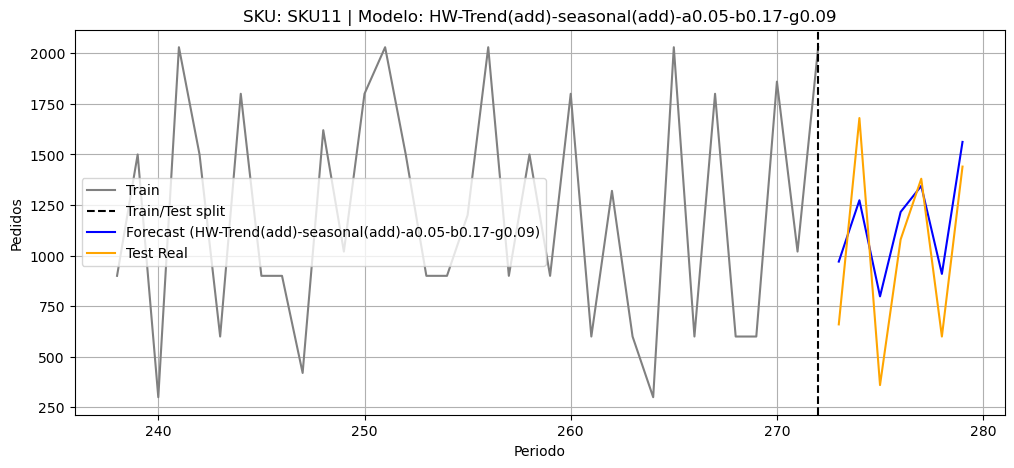

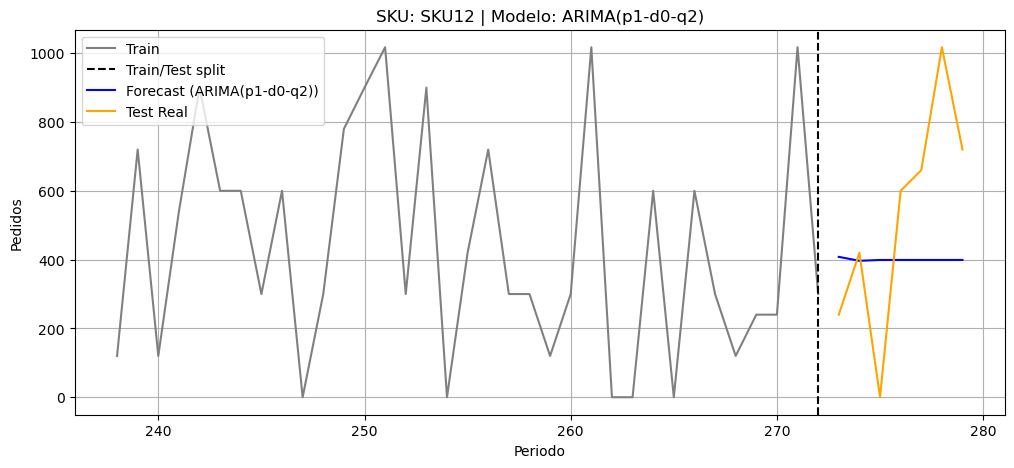

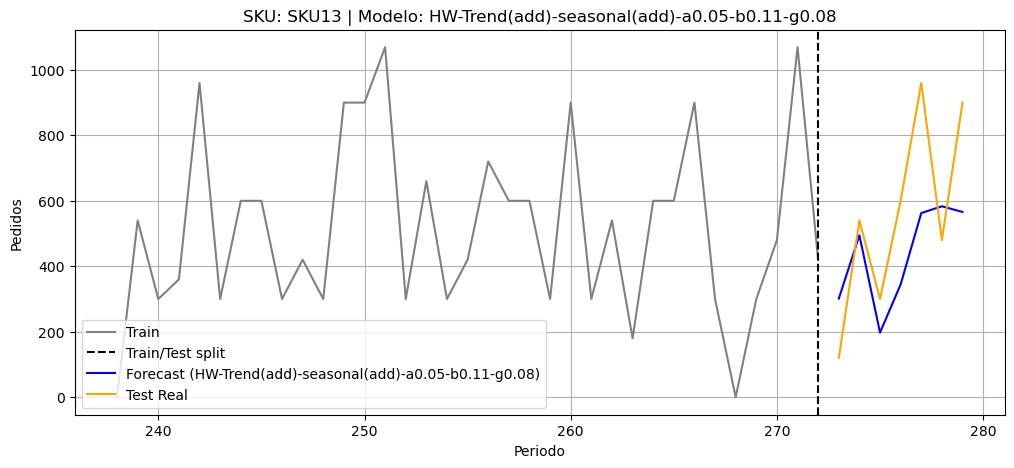

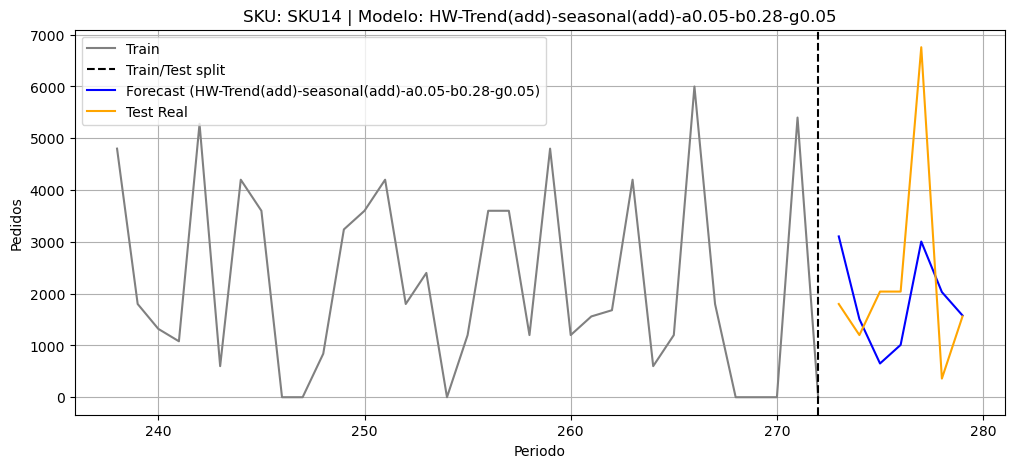

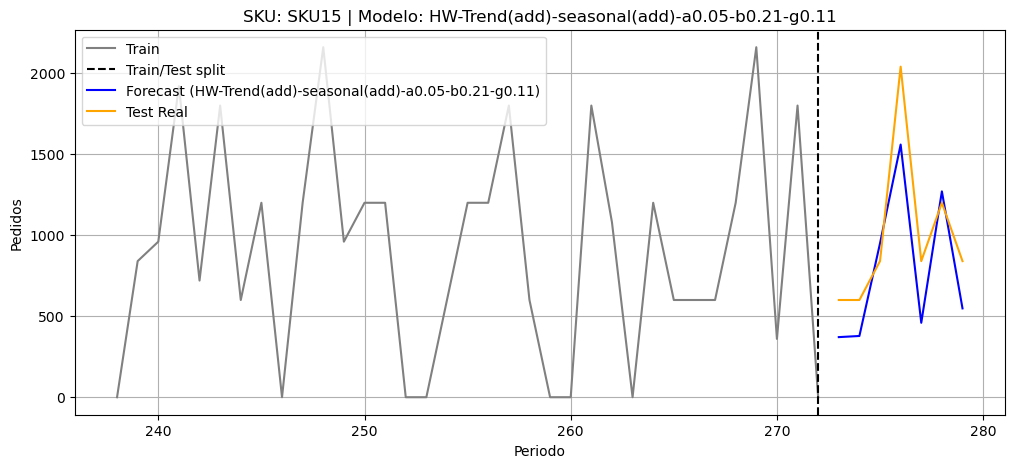

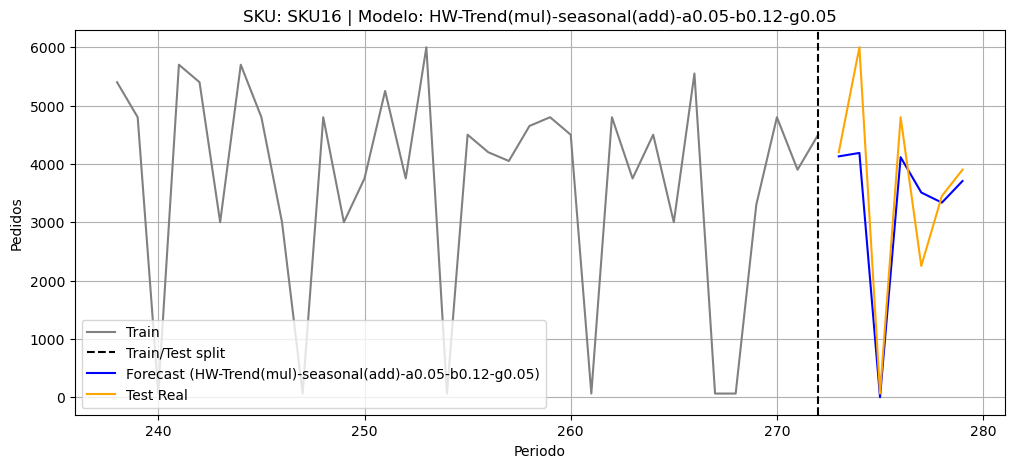

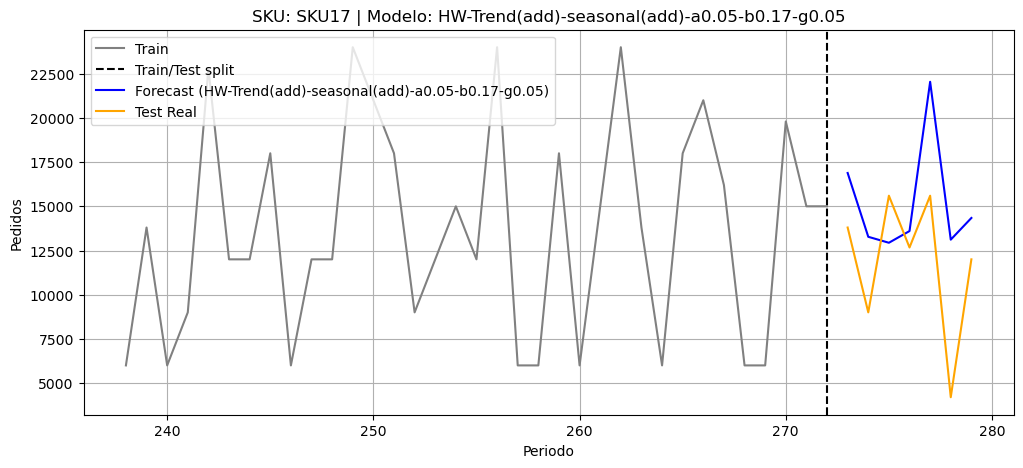

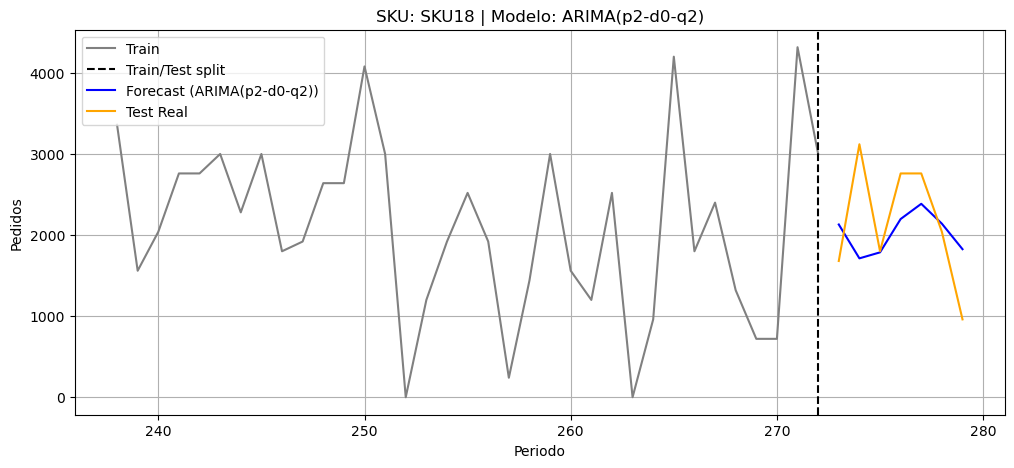

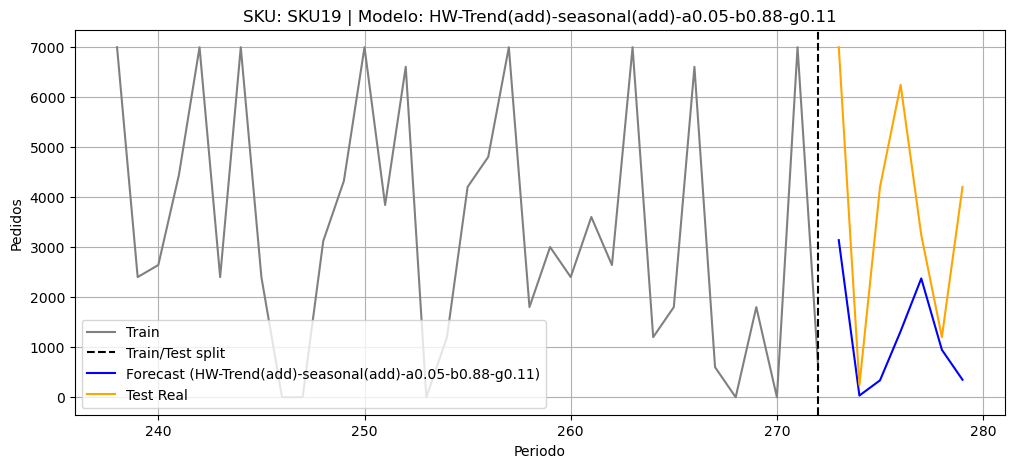

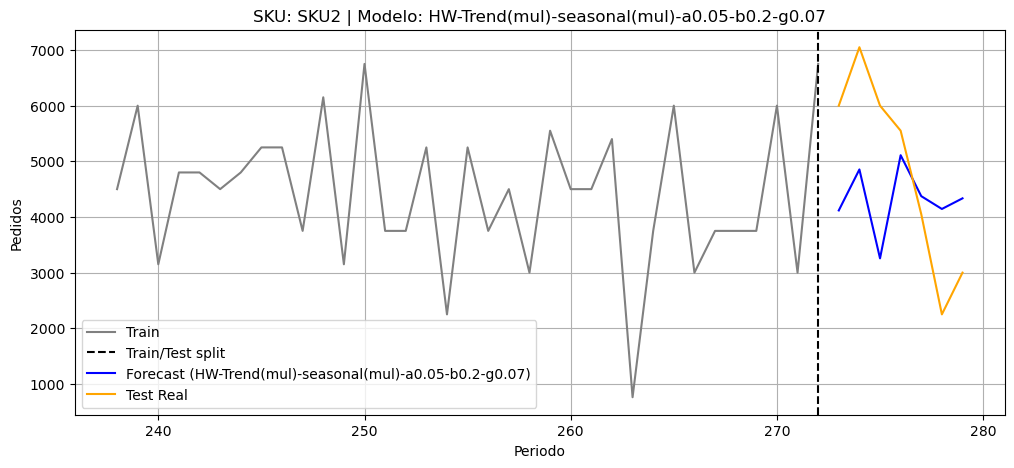

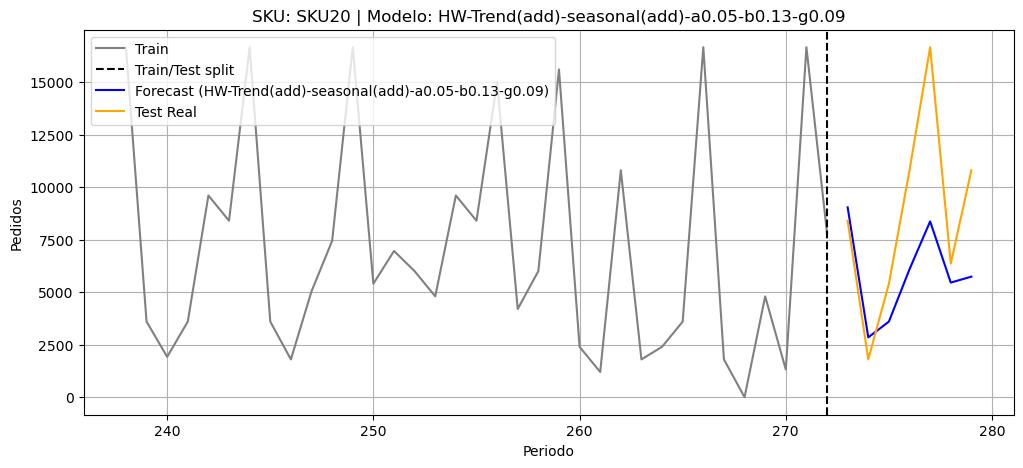

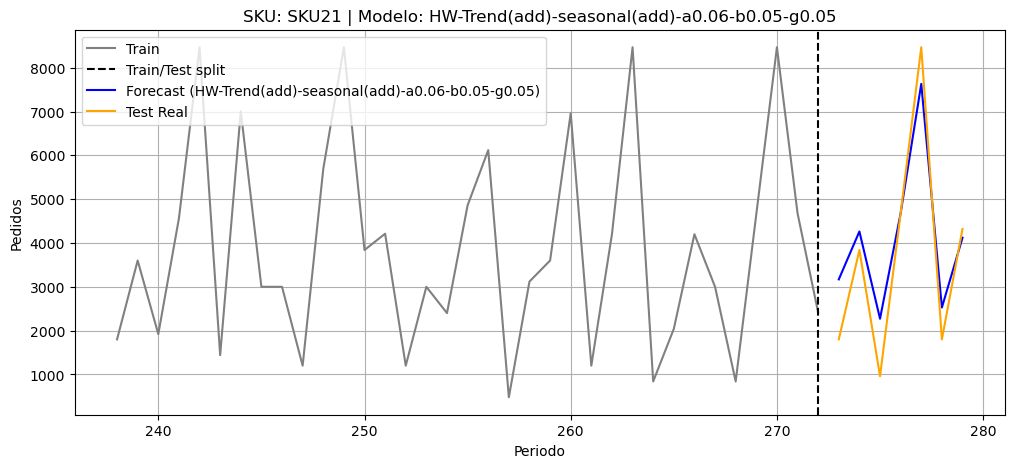

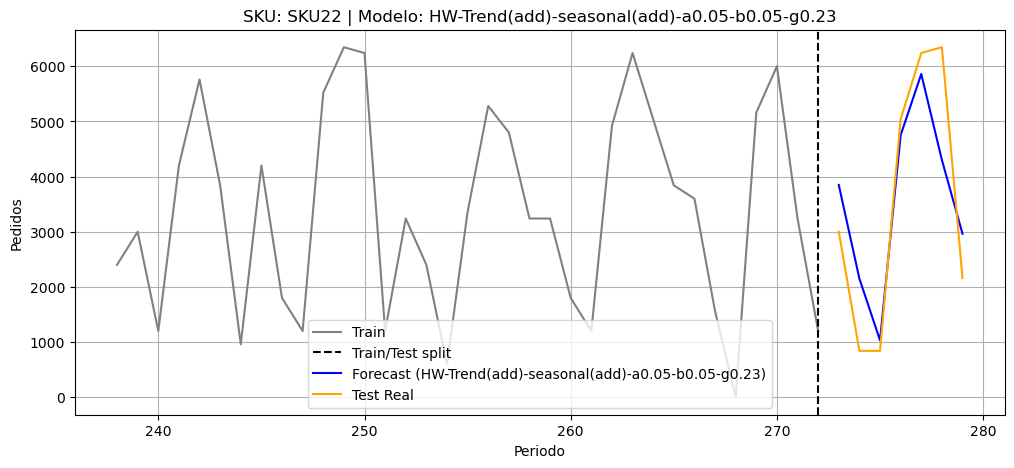

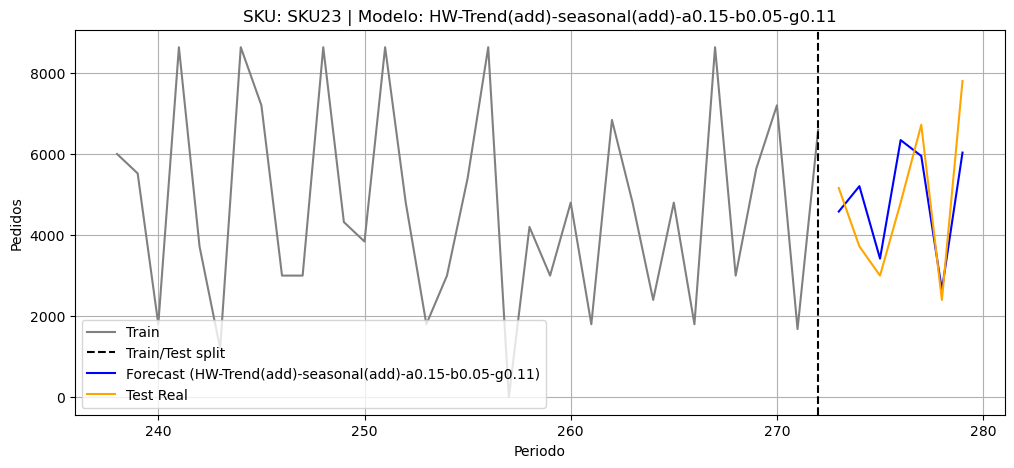

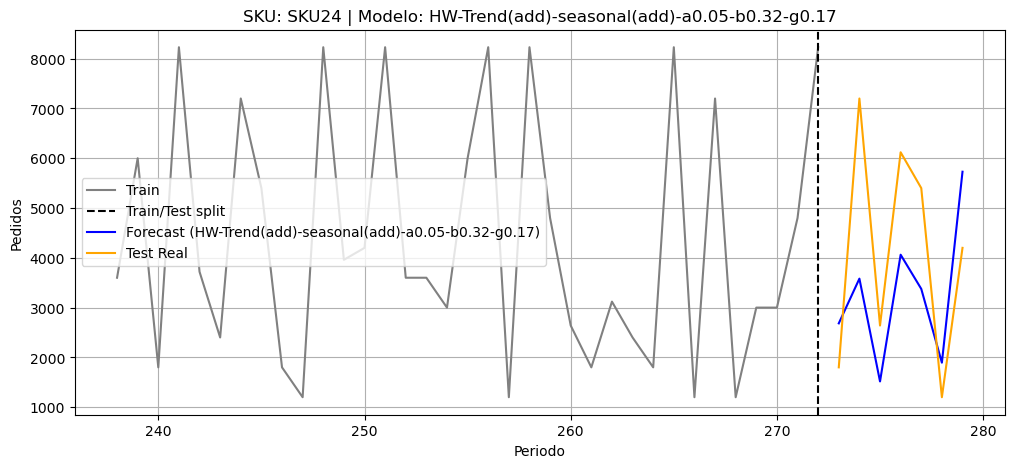

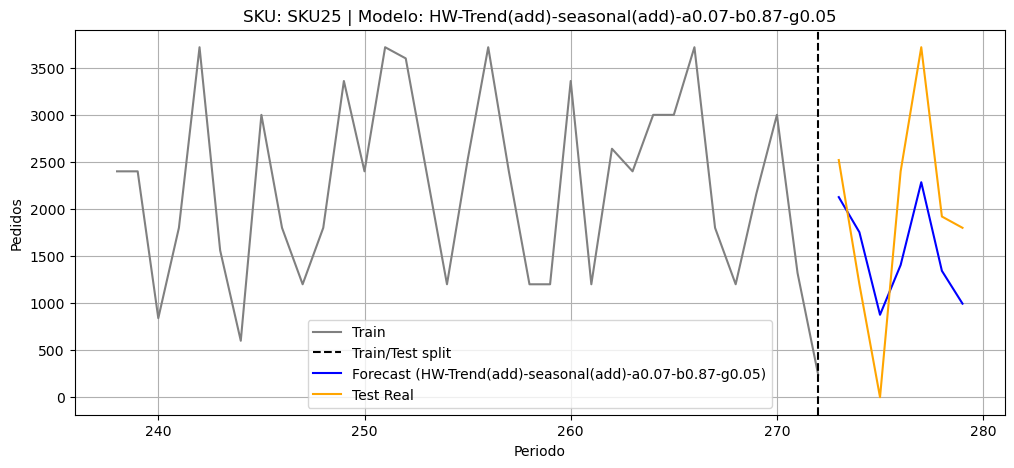

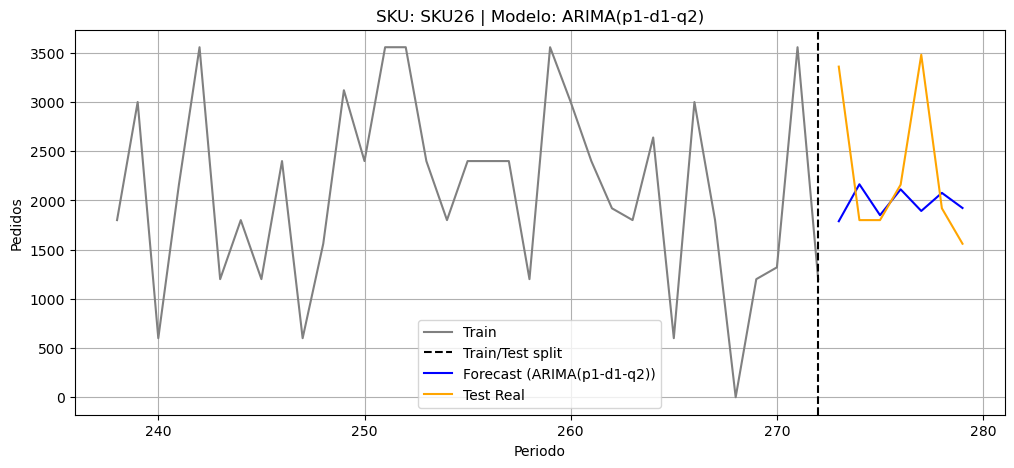

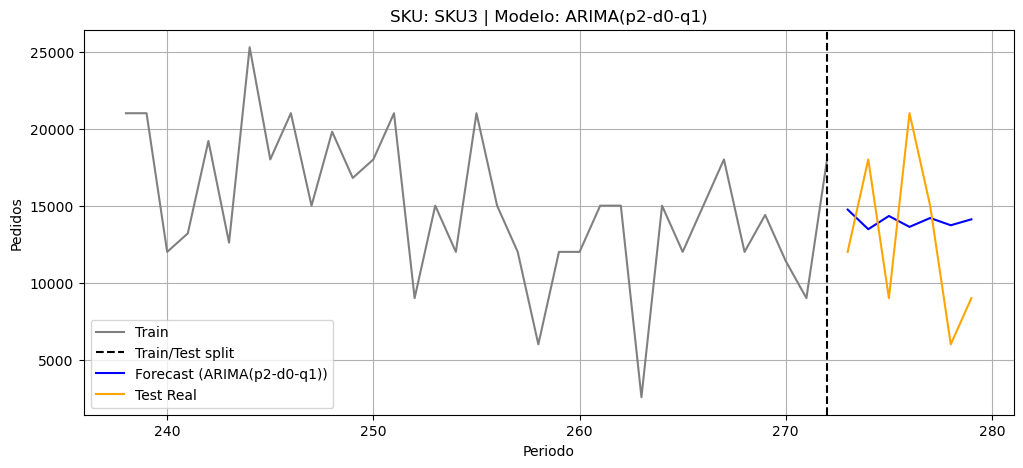

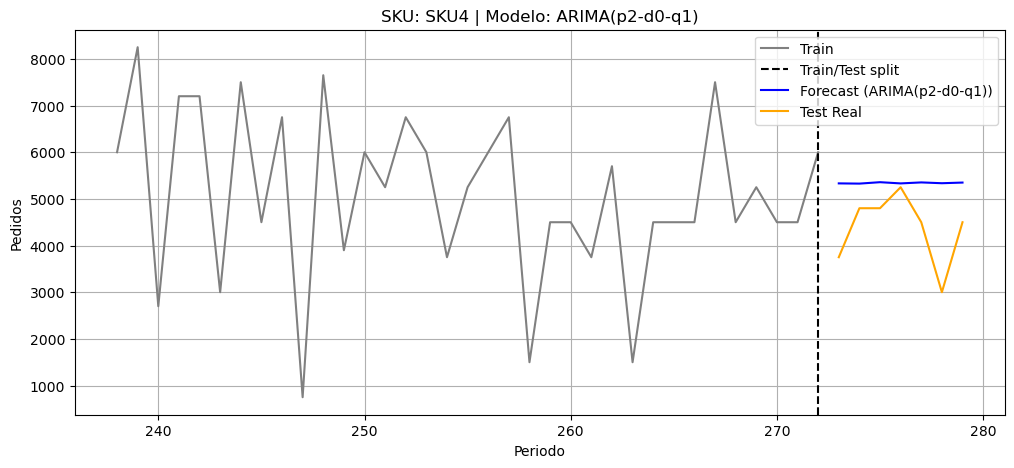

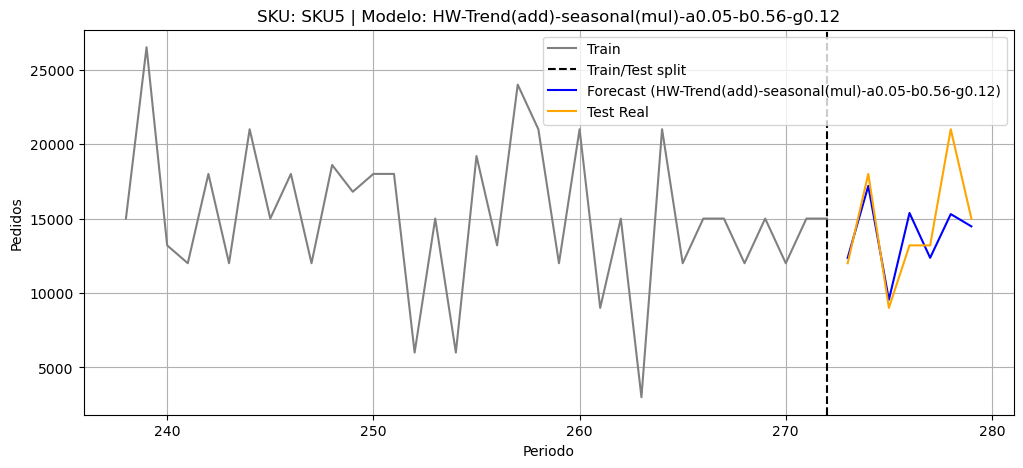

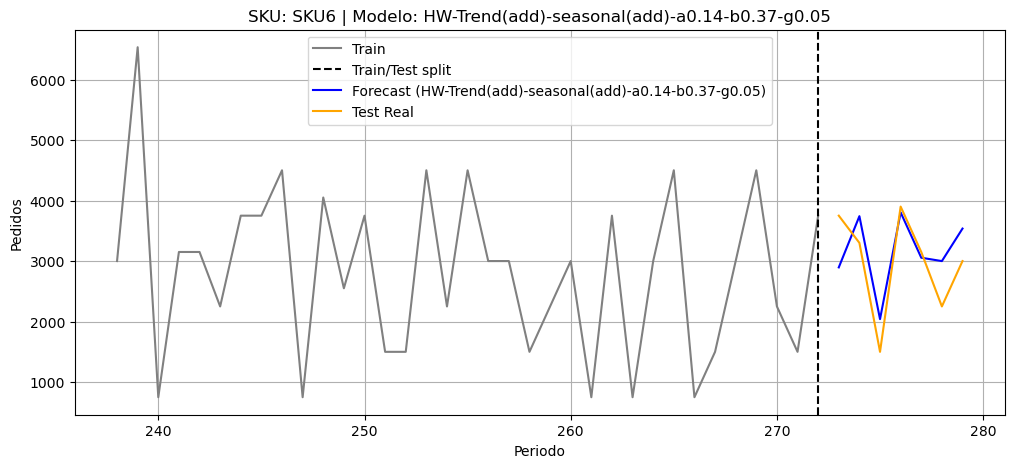

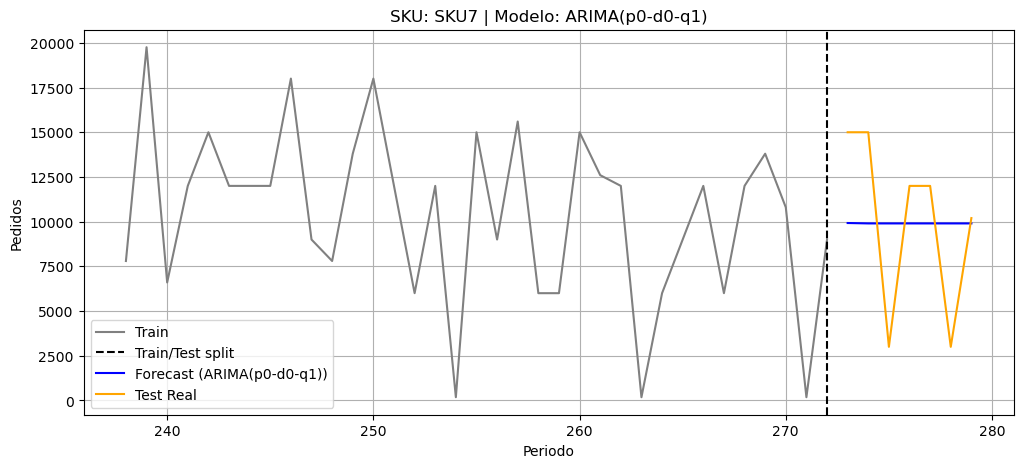

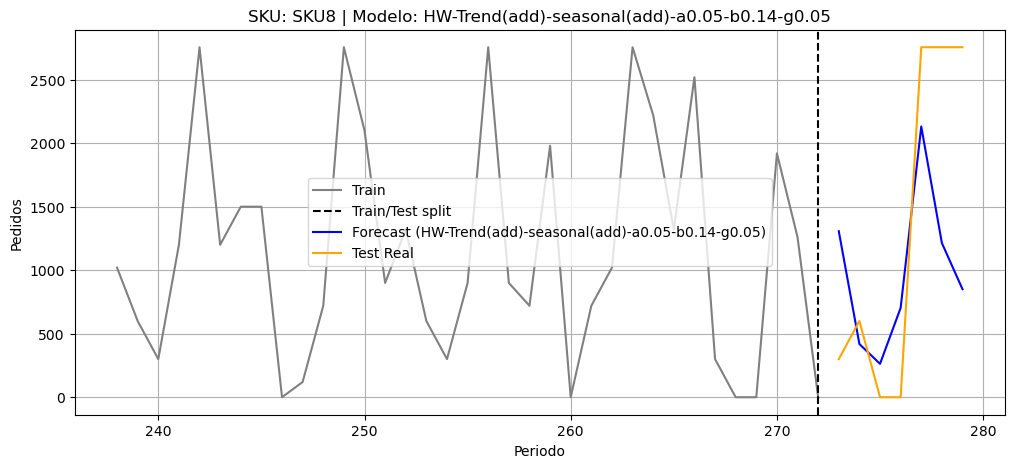

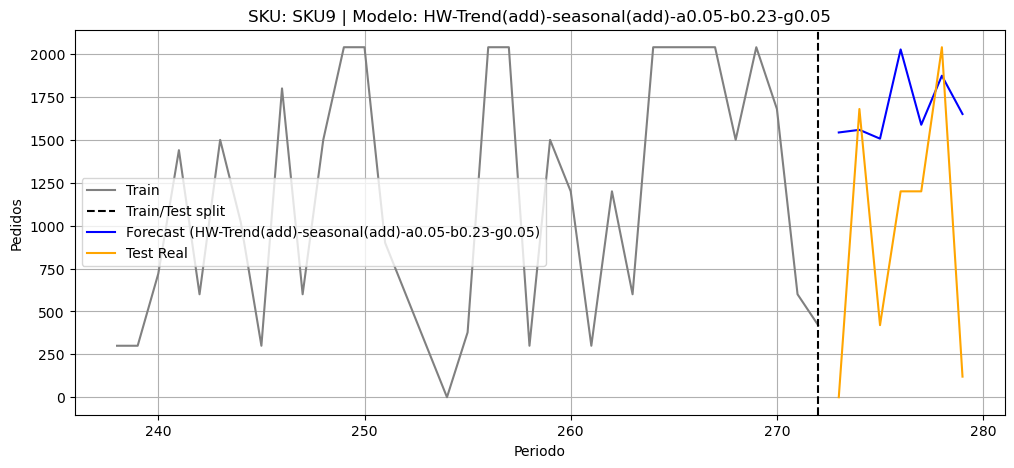

In [30]:
# Visualizar gráficas una por una con vista enfocada
#for _, row in df_forecast_summary.iterrows():
df_cleaned2 = df.groupby("SKU").apply(correct_outliers).reset_index(drop=True)
for _, row in resultados_futuro_df.iterrows():
    plot_forecast_focus(df_cleaned2, row["SKU"], row)